<a href="https://colab.research.google.com/github/saraharafa/MachineLearningProject01/blob/main/nlp01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 1: Setup**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
link = "https://raw.githubusercontent.com/UmmeKulsumTumpa/Sentiment-Analysis-IMDB-Movie-Reviews/master/IMDB%20Dataset.csv"
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
import joblib

# **TASK 2: Load & Explore Data**

In [ ]:
df = pd.read_csv(link)
print("First 5 ROWS:")
print(df.head().T)

First 5 ROWS:
                                                           0  \
review     One of the other reviewers has mentioned that ...   
sentiment                                           positive   

                                                           1  \
review     A wonderful little production. <br /><br />The...   
sentiment                                           positive   

                                                           2  \
review     I thought this was a wonderful way to spend ti...   
sentiment                                           positive   

                                                           3  \
review     Basically there's a family where a little boy ...   
sentiment                                           negative   

                                                           4  
review     Petter Mattei's "Love in the Time of Money" is...  
sentiment                                           positive  


In [ ]:
#Dataset shapes and label counts:
print("Dataset Shape:\n",df.shape)
print("\nLabel Counts:\n",df['sentiment'].value_counts())

Dataset Shape:
 (50000, 2)

Label Counts:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


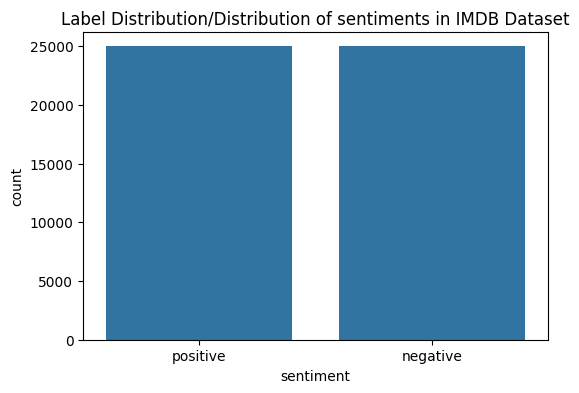

In [ ]:
#Plot label distribution using seaborn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment')
plt.title('Label Distribution/Distribution of sentiments in IMDB Dataset')
plt.show()


# **TASK 3: Preprocess Text**

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
#English stopwords
stop_words = set(stopwords.words('english'))
def clean_text_func(text):
  text = text.lower()
  #Remove punctuation, numbers, HTML tags
  text = re.sub(r'<([a-z]+)[^>]*>.*?</\1>', ' ', text)
  text = re.sub(r'<.*?>', ' ', text)
  text = re.sub(r'[^a-z\s]', '', text) #remove punct n' numbers
  #Remove English stopwords
  words = text.split()
  cleaned_words = [word for word in words if word not in stop_words]
  return ' '.join(cleaned_words)

df['clean_text'] = df['review'].apply(clean_text_func) #new column clean_words
print(df.head())



                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                          clean_text  
0  one reviewers mentioned watching oz episode yo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically theres family little boy jake thinks...  
4  petter matteis love time money visually stunni...  


# **TASK 4: Encode Labels**

In [ ]:
#Convert sentiment to numeric:+ve:1,-ve:0,
#store in label_encoded
df['label_encoded'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df.head(10))

                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   
5  Probably my all-time favorite movie, a story o...  positive   
6  I sure would like to see a resurrection of a u...  positive   
7  This show was an amazing, fresh & innovative i...  negative   
8  Encouraged by the positive comments about this...  negative   
9  If you like original gut wrenching laughter yo...  positive   

                                          clean_text  label_encoded  
0  one reviewers mentioned watching oz episode yo...              1  
1  wonderful little production filming technique ...              1  
2  thought wonderful way spend time hot summer we...           

# **TASK 5: Train/Test Split**

In [ ]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
print(f"X_train shape: {X_train.shape}, y_train:{y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test:{y_test.shape}")

X_train shape: (40000,), y_train:(40000,)
X_test shape: (10000,), y_test:(10000,)


# **TASK 6: Feauture Extraction**

In [ ]:
#Use TF-IDF vectorizer
#Limit max features to 5000
tfidf = TfidfVectorizer(max_features=5000)
#Fit on training data and transform train/test sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"IF-IDF Training data shape: {X_train_tfidf.shape}")
print(f"IF-IDF Testing data shape: {X_test_tfidf.shape}")



IF-IDF Training data shape: (40000, 5000)
IF-IDF Testing data shape: (10000, 5000)


# **TASK 7: Train ML Models**

In [ ]:
#Train Logistic Regression, SVM(linear), Random Forest
#1. Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
#2. SVM(Linear)
svm_model = LinearSVC(random_state=42)
#3. Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
#Train on TF-IDF
print("Training Logistic Regression now...\n")
log_reg.fit(X_train_tfidf, y_train)
print("Training Linear SVM now...:\n")
svm_model.fit(X_train_tfidf, y_train)
print(f"Training Random Forest now...:\n")
rf_model.fit(X_train_tfidf, y_train)

Training Logistic Regression now...

Training Linear SVM now...:

Training Random Forest now...:



RandomForestClassifier(random_state=42)

In [ ]:
#PRedict on test set
ypred_log_reg = log_reg.predict(X_test_tfidf)
ypred_svm = svm_model.predict(X_test_tfidf)
ypred_rf = rf_model.predict(X_test_tfidf)
print("Model trainig and prediction is done!!")

Model trainig and prediction is done!!


# **TASK 8: Evaluate Models**

In [ ]:
#Print accuracy, and classification report
accuracy_log_reg = accuracy_score(y_test, ypred_log_reg)
accuracy_svm = accuracy_score(y_test, ypred_svm)
accuracy_rf = accuracy_score(y_test, ypred_rf)
print(f"Accuracy of Logistic Regression: {accuracy_log_reg}\n")
print(f"Accuracy of Linear SVM: {accuracy_svm}\n")
print(f"Accuracy of Random Forest: {accuracy_rf}\n")
#Print classification report for each model
print(f"Classification Report of Logistic Regression: {classification_report(y_test, ypred_log_reg)}")
print(f"Classification Report of Linear SVM: {classification_report(y_test, ypred_svm)}")
print(f"Classification Report of Random Forest: {classification_report(y_test, ypred_rf)}")
#Print confusion matrix for each model
cm_log_reg = confusion_matrix(y_test, ypred_log_reg)
cm_svm = confusion_matrix(y_test, ypred_svm)
cm_rf = confusion_matrix(y_test, ypred_rf)

Accuracy of Logistic Regression: 0.8894

Accuracy of Linear SVM: 0.88

Accuracy of Random Forest: 0.8543

Classification Report of Logistic Regression:               precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Classification Report of Linear SVM:               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Classification Report of Random Forest:               precision    recall  f1-score   support

           0       0.84      0.87      0.86      4961
        

In [ ]:
#Compare model performance and decide which is best
performance = max(accuracy_log_reg, accuracy_svm, accuracy_rf)
if performance == accuracy_log_reg:
  print("Logistic Regression has the best performance so it is the best model!!")
elif performance == accuracy_svm:
  print("Linear SVM is the best model")
else:
  print("Random Forest is the best model")

Logistic Regression is the best model


# **TASK 9: Optional Extensions:😍😍**

In [ ]:
#Try CountVectorizer and compare
cv = CountVectorizer(max_features=5000)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.fit_transform(X_test)
#Train using the best model Log_Reg and predict
log_reg_cv = LogisticRegression(random_state = 42, max_iter = 1000)
log_reg_cv.fit(X_train_cv, y_train)
ypred_cv = log_reg_cv.predict(X_test_cv)
accuracy_cv = accuracy_score(y_test, ypred_cv)
print(f"Logistic Regression with Count Vectorizer Accuracy is:{accuracy_cv}")
print("The best model is: ")
if accuracy_log_reg > accuracy_cv:
  print("Logistic Regression with TF-IDF.\n")
else:
  print("Logistic Regression with Count Vectorizer.\n")

Logistic Regression with Count Vectorizer Accuracy is:0.5166
The best model is: 
Logistic Regression with TF-IDF.



In [ ]:
#Hyperparameter tuning with GridSearchCV
param_grid = {'C': [0.001, 0.01, 1, 10],
              'penalty':['l1','l2'],
              'solver':['liblinear','saga']
}
grid_search = GridSearchCV(LogisticRegression(random_state=42,max_iter = 1000), param_grid, cv=5,
                           n_jobs=-1,
                           verbose=1
)
grid_search.fit(X_train_tfidf, y_train)
best_params = grid_search.best_params_
print(f"Best Hyperparameters Found: {best_params}")
print(f"Best Cross-Validation Score: {grid_search.best_score_}")
best_log_reg_model = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters Found: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.8882750000000001


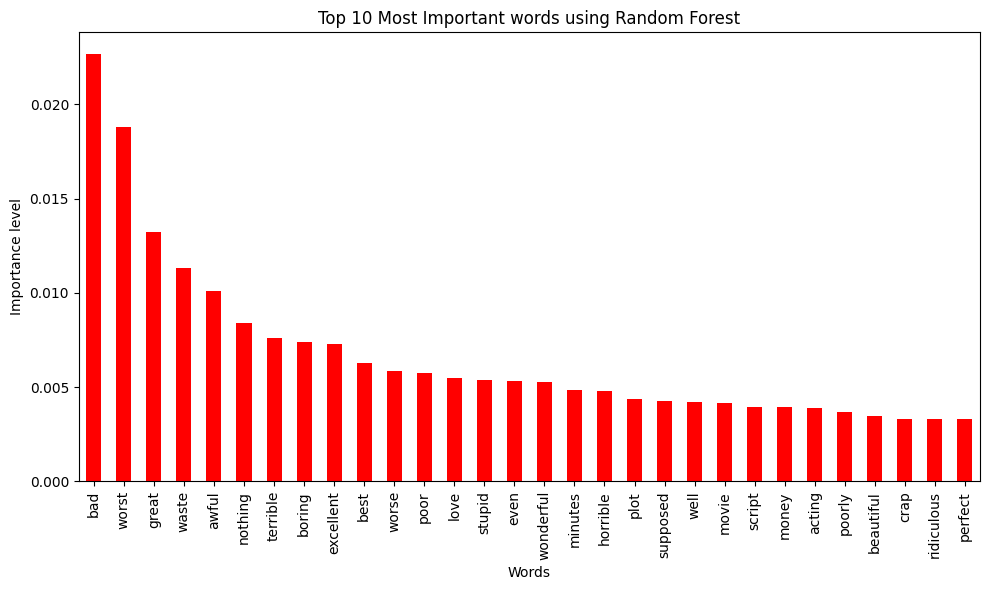

In [ ]:
#Plot feature Importance for Random Forest
features = tfidf.get_feature_names_out()
f_importance = rf_model.feature_importances_
rf_importance = pd.Series(f_importance, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
rf_importance.head(30).plot(kind='bar',color ='red')
plt.title('Top 10 Most Important words using Random Forest')
plt.ylabel('Importance level')
plt.xlabel('Words')
plt.tight_layout()
plt.show()

In [ ]:
#Save best model/vectorizer using joblib
joblib.dump(tfidf, 'tfidf_vectorizer_model.pkl')
joblib.dump(best_log_reg_model, 'best_sentiment_model.pkl')


['best_sentiment_model.pkl']